In [4]:
import fiftyone as fo 
import fiftyone.brain as fob # ML methods
import fiftyone.zoo as foz # zoo datasets and models
from fiftyone import ViewField as F # helper for defining views
import os

In [ ]:
OBJECT="socket_pin"

# Initialize Dataset
if "socket_dataset" in fo.list_datasets():
    fo.delete_dataset("socket_dataset")
dataset = fo.Dataset("socket_dataset")

samples = []
data_path = "./datasets/socket_pins"

train_dir = os.path.join(data_path, "train", "good")
if os.path.exists(train_dir):
    for file in os.listdir(train_dir):
        if file.lower().endswith(('.jpg', '.png')):
            sample = fo.Sample(filepath=os.path.join(train_dir, file))
            sample["split"] = "train"
            sample["category"] = fo.Classification(label=OBJECT)
            sample["state"] = fo.Classification(label="good")
            samples.append(sample)

test_good_dir = os.path.join(data_path, "test", "good")
if os.path.exists(test_good_dir):
    for file in os.listdir(test_good_dir):
        if file.lower().endswith(('.jpg', '.png')):
            sample = fo.Sample(filepath=os.path.join(test_good_dir, file))
            sample["split"] = "test"
            sample["category"] = fo.Classification(label=OBJECT)
            sample["state"] = fo.Classification(label="good")
            samples.append(sample)

dataset.add_samples(samples)
print(f"Loaded {len(samples)} samples.")

In [ ]:
""" model = foz.load_zoo_model("clip-vit-base32-torch") """
model = foz.load_zoo_model("resnet50-imagenet-torch")

# Compute embeddings for the dataset
""" dataset.compute_embeddings(model=model, embeddings_field="clip_embeddings") """
dataset.compute_embeddings(model=model, embeddings_field="resnet50_embeddings")

# Dimensionality reduction using UMAP on the embeddings
fob.compute_visualization(dataset, embeddings="resnet50_embeddings", method="umap", brain_key="resnet50_vis")

In [ ]:
from sklearn.cluster import KMeans, HDBSCAN
import numpy as np

In [ ]:
# Extract the embeddings from the dataset
view = dataset.exists("resnet50_embeddings")
embeddings = np.stack(view.values("resnet50_embeddings"))

# KMeans clustering
num_clusters = 4 
kmeans = KMeans(n_clusters=num_clusters, random_state=42, n_init=10)
clusters = kmeans.fit_predict(embeddings)

# Add the cluster IDs back to the dataset as a new field
dataset.set_values("cluster_id", [str(c) for c in clusters])
print(f"Assigned {len(clusters)} samples to {num_clusters} clusters.")

""" # HDBSCAN clustering
hdbscan = HDBSCAN(min_cluster_size=5, metric='euclidean')
clusters_hbd = hdbscan.fit_predict(embeddings)

dataset.set_values("cluster_id_hdb", [str(c) for c in clusters_hbd])
print(f"Assigned {len(clusters_hbd)} samples to clusters.") """

In [ ]:
""" cluster_1_view = dataset.match(F("cluster_id") == "1")
for sample in cluster_1_view:
    sample["state"].label = "missalinged/non-pin"
    sample.save() 

cluster_2_view = dataset.match(F("cluster_id") == "0")
for sample in cluster_2_view:
    sample["state"].label = "hole"
    sample.save()

cluster_3_view = dataset.match(F("cluster_id") == "2")
for sample in cluster_3_view:
    sample["state"].label = "pin"
    sample.save()  """

In [ ]:
session = fo.launch_app(dataset)

In [3]:
from anomalib.data import Folder
from anomalib.models import Padim, Patchcore
from anomalib.engine import Engine
import anomalib.models.components.sampling.k_center_greedy as k_center
from tqdm.notebook import tqdm
k_center.tqdm = tqdm
import torch
from torchvision.transforms.v2 import Resize
torch.set_float32_matmul_precision('medium')
# When initializing the Engine, replace the default progress bar
from lightning.pytorch.callbacks import TQDMProgressBar
from lightning.pytorch.callbacks import ModelCheckpoint, EarlyStopping

In [ ]:
def train_socket_inspector():    
    model = Patchcore(
        backbone="resnet34",  # Consistent with config
        layers=["layer2", "layer3"],
        coreset_sampling_ratio=0.25,  # Increased for better coverage
        num_neighbors=15,  # Increased for better scoring
    )
    
    datamodule = Folder(
        name="socket_pins",
        root="./datasets/socket_pins",
        normal_dir="train/good",
        abnormal_dir="test/defect",
        num_workers=8,
    )
    
    
    """ checkpoint_callback = ModelCheckpoint(
        dirpath="results/Patchcore/socket_pins/checkpoints",
        filename="best-{epoch:02d}-{image_F1Score:.2f}",
        save_top_k=3,
        monitor="image_F1Score",
        mode="max",
    )
    
    early_stop_callback = EarlyStopping(
        monitor="image_F1Score",
        patience=5,
        mode="max",
    ) """
    
    """
    model = Padim(backbone="resnet34")
    datamodule = Folder(
        name="socket_pins",
        root="./datasets/socket_pins",
        normal_dir="train/good",
        # abnormal_dir="test/defect",
        num_workers=8,
    )
    """

    engine = Engine(callbacks=[TQDMProgressBar()], max_epochs=50)
    """ callbacks=[checkpoint_callback, early_stop_callback], """
    
    engine.fit(datamodule=datamodule, model=model)
    engine.test(datamodule=datamodule, model=model)
    
    # Export with pixel-level predictions
    engine.export(
        model=model,
        export_type="torch",
        ckpt_path="./results/Patchcore/socket_pins/latest/weights/lightning/model.ckpt",
    )
    print("Model exported to .pt format successfully.")

train_socket_inspector()

In [1]:
from anomalib.deploy import TorchInferencer, OpenVINOInferencer
import cv2
import matplotlib.pyplot as plt
import dotenv
dotenv.load_dotenv()

True

TorchInferencer is a legacy inferencer. Consider using Engine.predict() instead, which provides a more modern and feature-rich interface for model inference.
TRUST_REMOTE_CODE is set to True. Loading model using pickle module, which is inherently insecure and can lead to arbitrary code execution. Only set this to True if you TRUST the source of the checkpoint.


Good


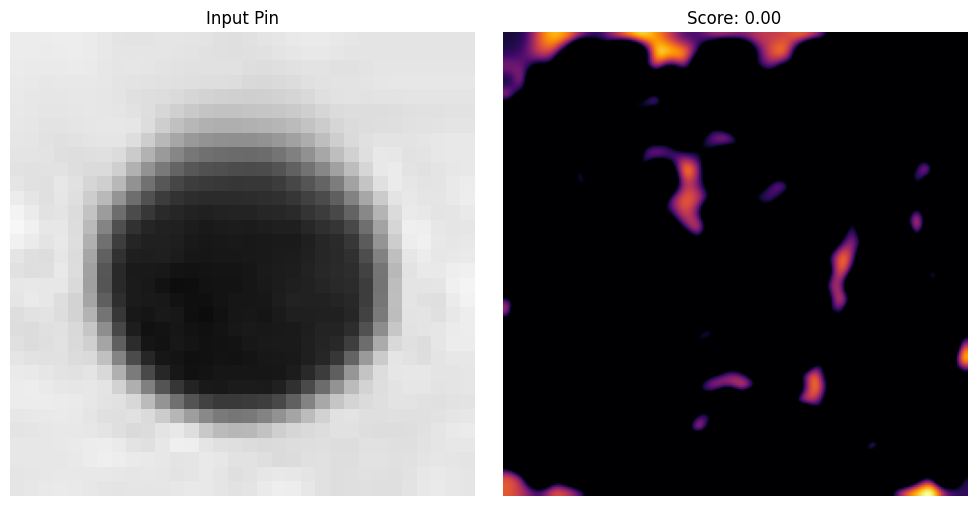

TorchInferencer is a legacy inferencer. Consider using Engine.predict() instead, which provides a more modern and feature-rich interface for model inference.
TRUST_REMOTE_CODE is set to True. Loading model using pickle module, which is inherently insecure and can lead to arbitrary code execution. Only set this to True if you TRUST the source of the checkpoint.


Anomalous


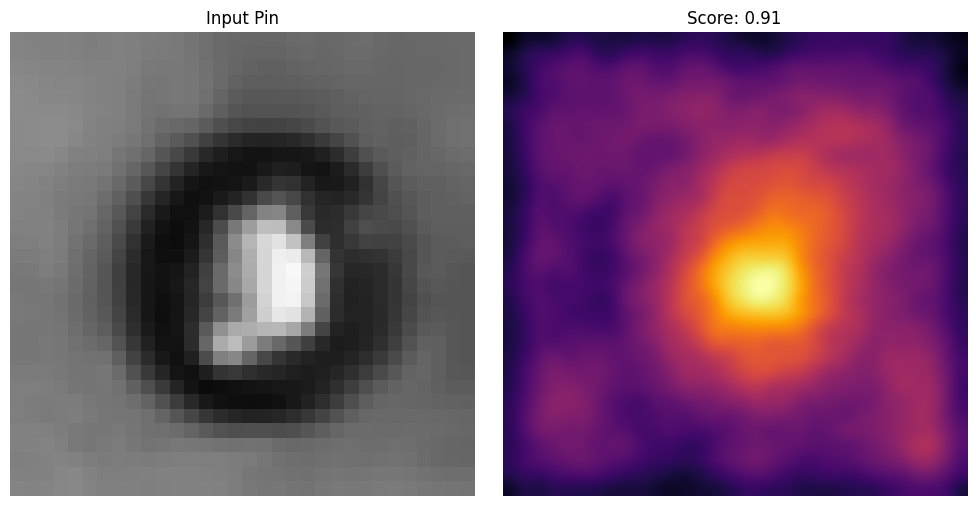

TorchInferencer is a legacy inferencer. Consider using Engine.predict() instead, which provides a more modern and feature-rich interface for model inference.
TRUST_REMOTE_CODE is set to True. Loading model using pickle module, which is inherently insecure and can lead to arbitrary code execution. Only set this to True if you TRUST the source of the checkpoint.


Good


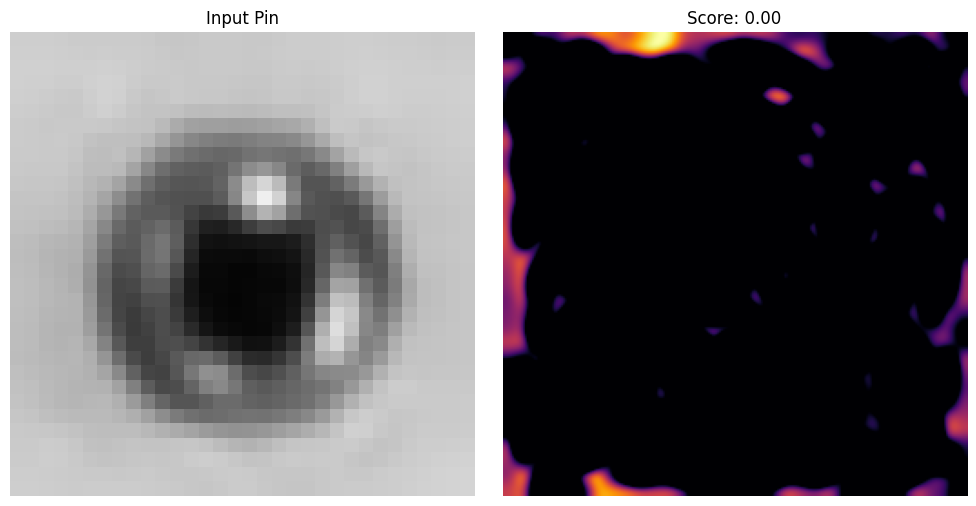

TorchInferencer is a legacy inferencer. Consider using Engine.predict() instead, which provides a more modern and feature-rich interface for model inference.
TRUST_REMOTE_CODE is set to True. Loading model using pickle module, which is inherently insecure and can lead to arbitrary code execution. Only set this to True if you TRUST the source of the checkpoint.


Good


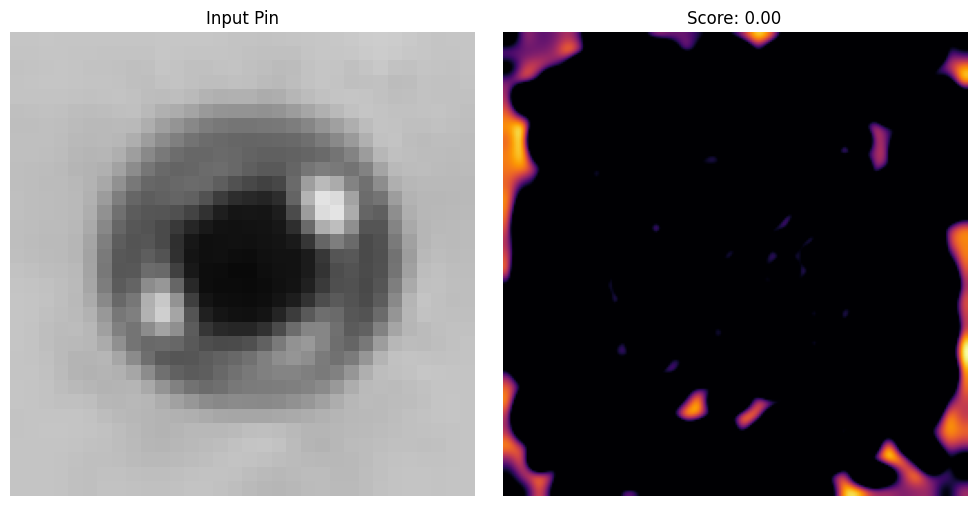

TorchInferencer is a legacy inferencer. Consider using Engine.predict() instead, which provides a more modern and feature-rich interface for model inference.
TRUST_REMOTE_CODE is set to True. Loading model using pickle module, which is inherently insecure and can lead to arbitrary code execution. Only set this to True if you TRUST the source of the checkpoint.


Good


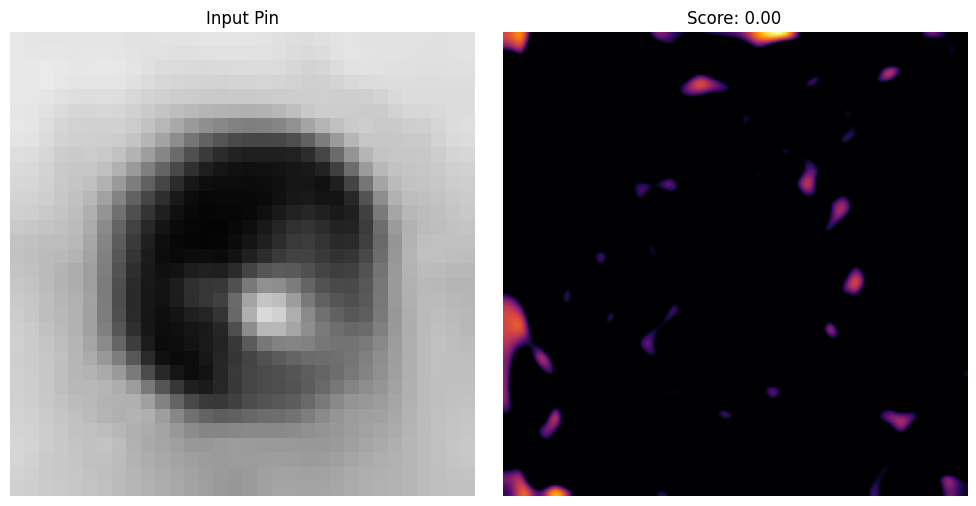

TorchInferencer is a legacy inferencer. Consider using Engine.predict() instead, which provides a more modern and feature-rich interface for model inference.
TRUST_REMOTE_CODE is set to True. Loading model using pickle module, which is inherently insecure and can lead to arbitrary code execution. Only set this to True if you TRUST the source of the checkpoint.


Good


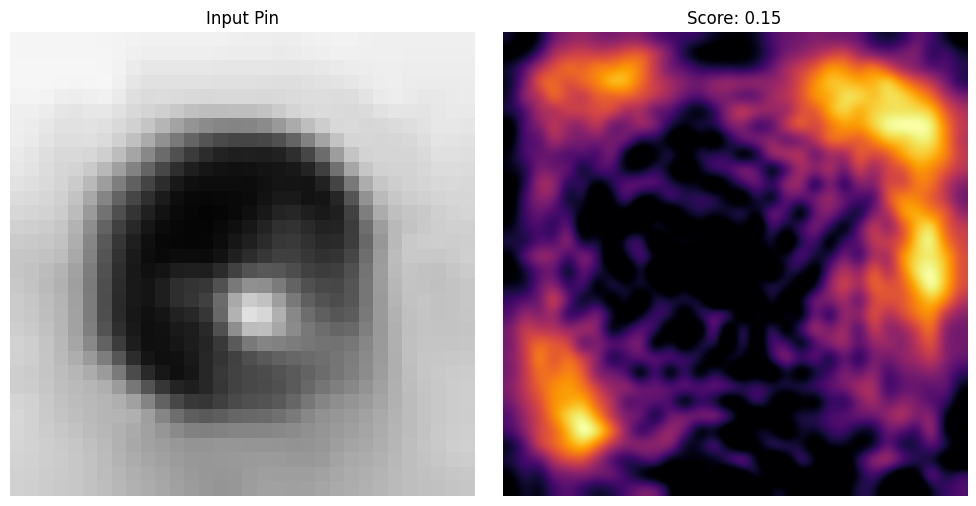

TorchInferencer is a legacy inferencer. Consider using Engine.predict() instead, which provides a more modern and feature-rich interface for model inference.
TRUST_REMOTE_CODE is set to True. Loading model using pickle module, which is inherently insecure and can lead to arbitrary code execution. Only set this to True if you TRUST the source of the checkpoint.


Anomalous


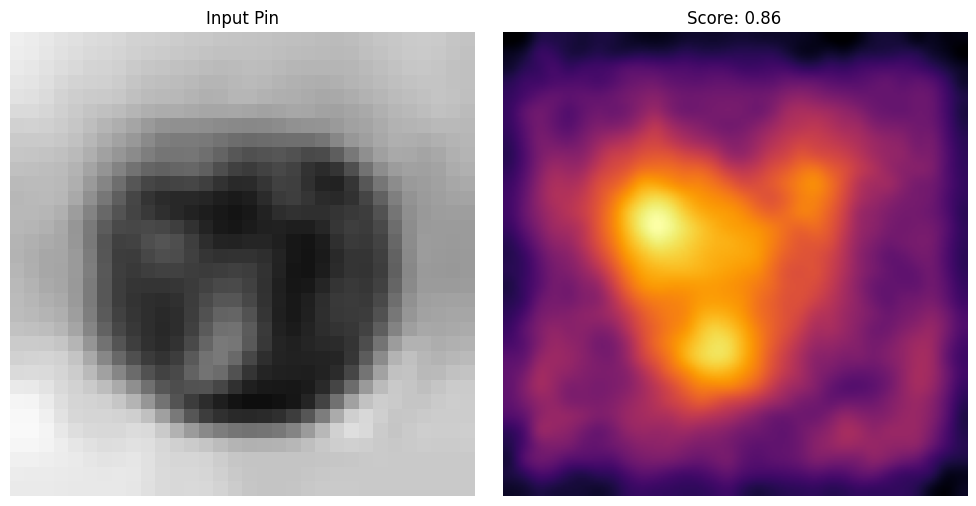

TorchInferencer is a legacy inferencer. Consider using Engine.predict() instead, which provides a more modern and feature-rich interface for model inference.
TRUST_REMOTE_CODE is set to True. Loading model using pickle module, which is inherently insecure and can lead to arbitrary code execution. Only set this to True if you TRUST the source of the checkpoint.


Anomalous


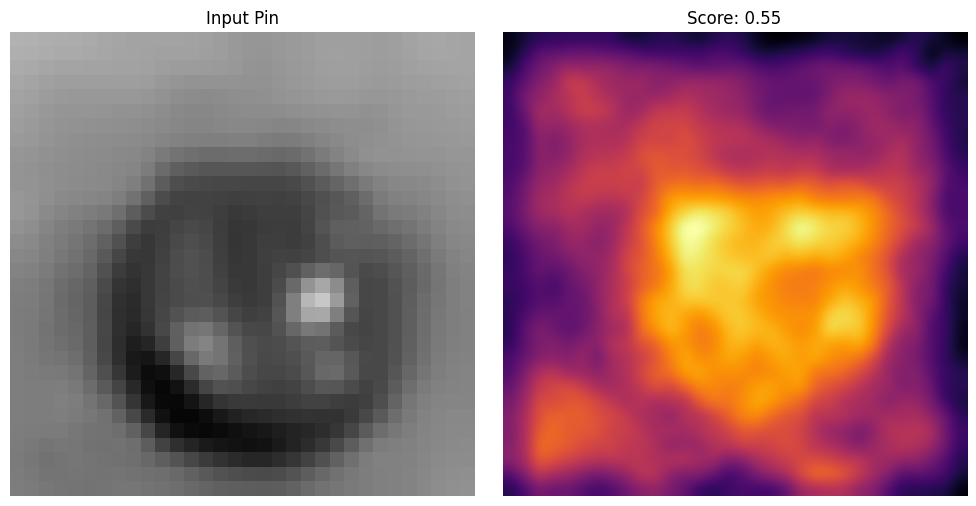

TorchInferencer is a legacy inferencer. Consider using Engine.predict() instead, which provides a more modern and feature-rich interface for model inference.
TRUST_REMOTE_CODE is set to True. Loading model using pickle module, which is inherently insecure and can lead to arbitrary code execution. Only set this to True if you TRUST the source of the checkpoint.


Anomalous


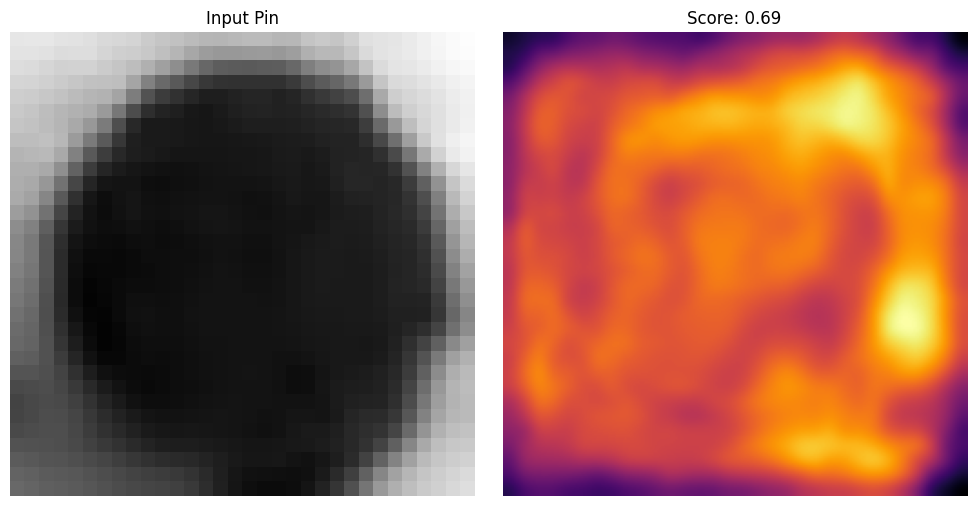

TorchInferencer is a legacy inferencer. Consider using Engine.predict() instead, which provides a more modern and feature-rich interface for model inference.
TRUST_REMOTE_CODE is set to True. Loading model using pickle module, which is inherently insecure and can lead to arbitrary code execution. Only set this to True if you TRUST the source of the checkpoint.


Anomalous


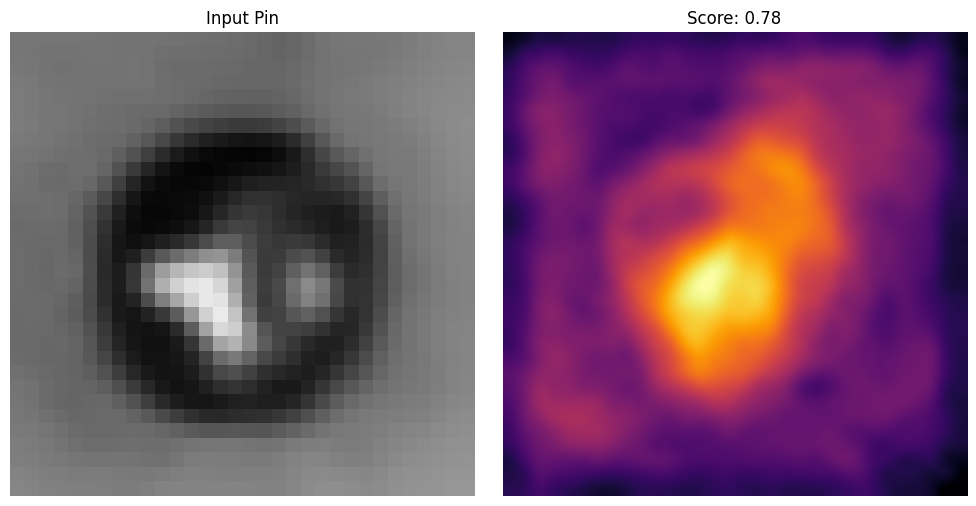

TorchInferencer is a legacy inferencer. Consider using Engine.predict() instead, which provides a more modern and feature-rich interface for model inference.
TRUST_REMOTE_CODE is set to True. Loading model using pickle module, which is inherently insecure and can lead to arbitrary code execution. Only set this to True if you TRUST the source of the checkpoint.


Anomalous


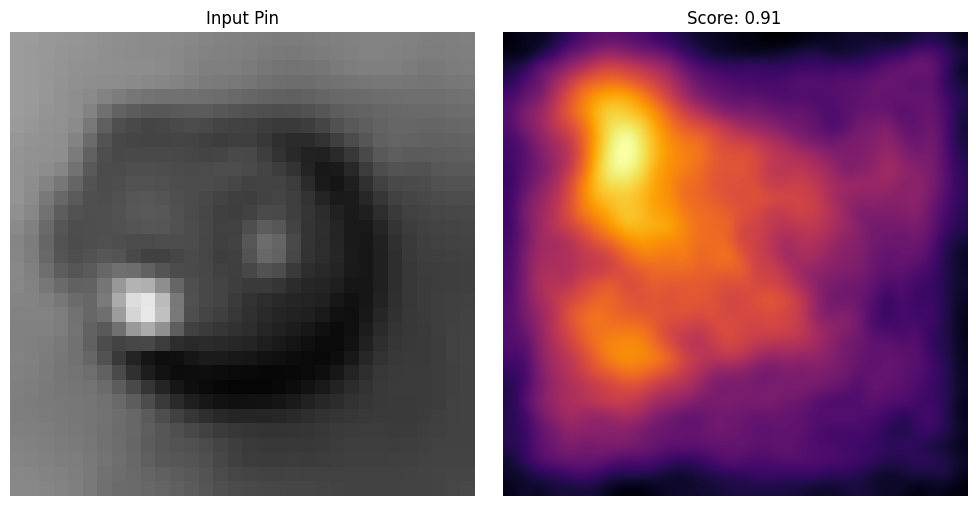

TorchInferencer is a legacy inferencer. Consider using Engine.predict() instead, which provides a more modern and feature-rich interface for model inference.
TRUST_REMOTE_CODE is set to True. Loading model using pickle module, which is inherently insecure and can lead to arbitrary code execution. Only set this to True if you TRUST the source of the checkpoint.


Good


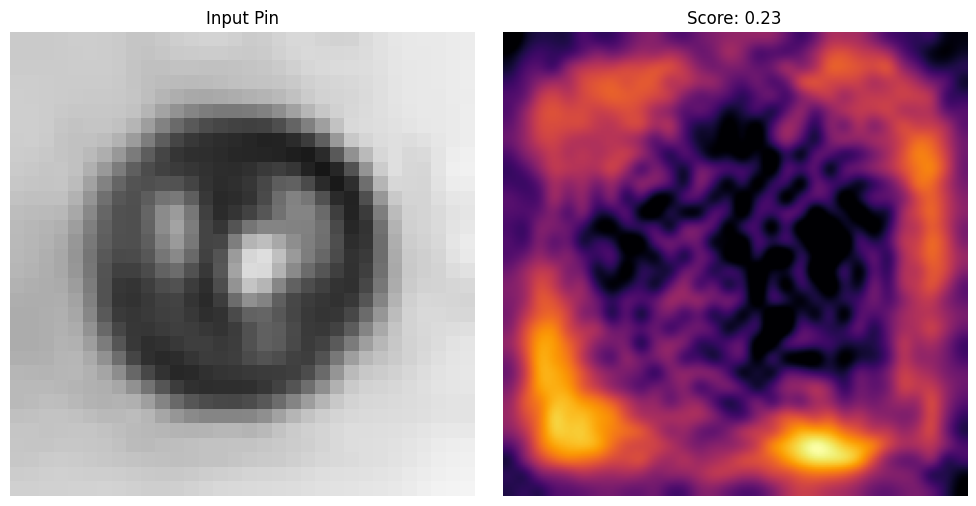

TorchInferencer is a legacy inferencer. Consider using Engine.predict() instead, which provides a more modern and feature-rich interface for model inference.
TRUST_REMOTE_CODE is set to True. Loading model using pickle module, which is inherently insecure and can lead to arbitrary code execution. Only set this to True if you TRUST the source of the checkpoint.


Anomalous


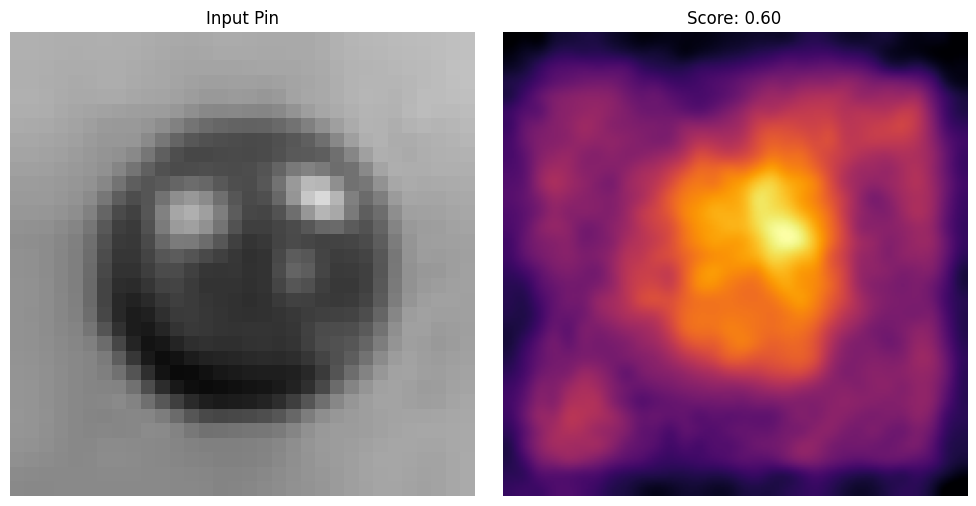

TorchInferencer is a legacy inferencer. Consider using Engine.predict() instead, which provides a more modern and feature-rich interface for model inference.
TRUST_REMOTE_CODE is set to True. Loading model using pickle module, which is inherently insecure and can lead to arbitrary code execution. Only set this to True if you TRUST the source of the checkpoint.


Good


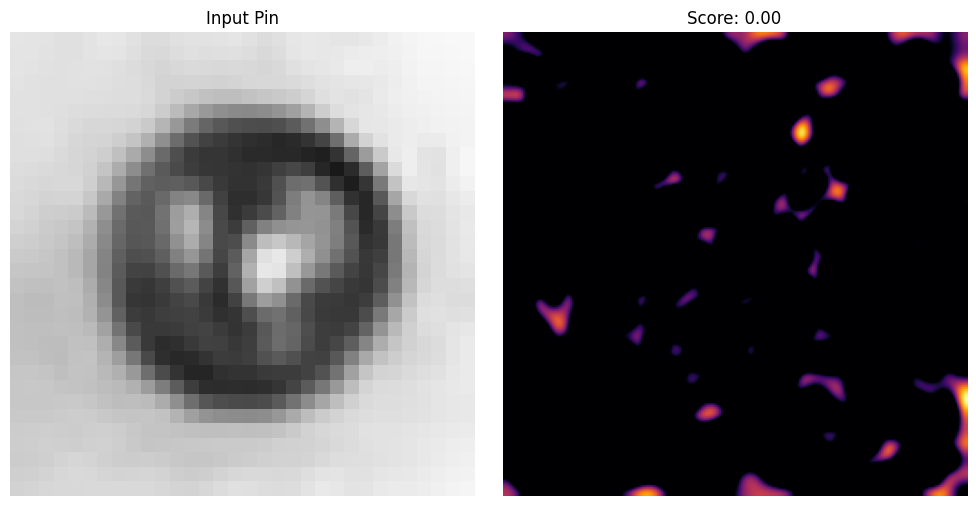

TorchInferencer is a legacy inferencer. Consider using Engine.predict() instead, which provides a more modern and feature-rich interface for model inference.
TRUST_REMOTE_CODE is set to True. Loading model using pickle module, which is inherently insecure and can lead to arbitrary code execution. Only set this to True if you TRUST the source of the checkpoint.


Anomalous


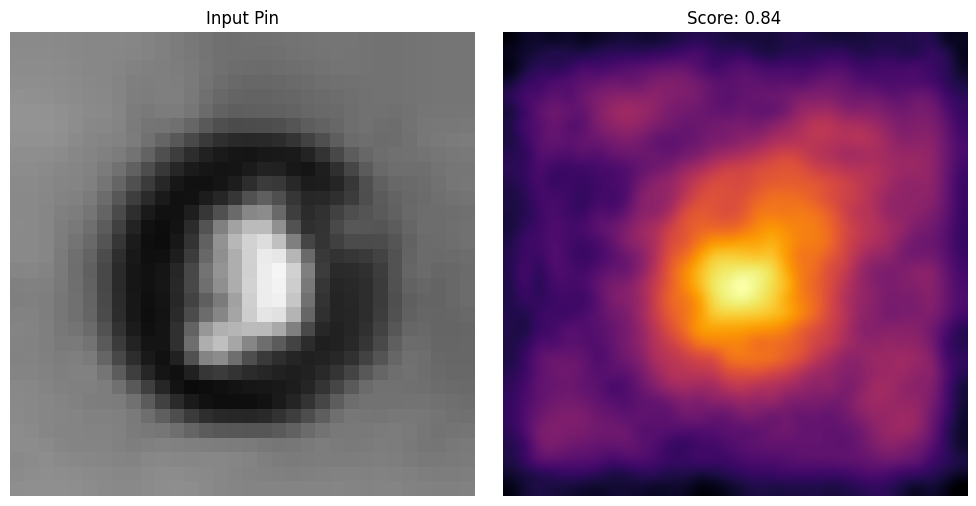

TorchInferencer is a legacy inferencer. Consider using Engine.predict() instead, which provides a more modern and feature-rich interface for model inference.
TRUST_REMOTE_CODE is set to True. Loading model using pickle module, which is inherently insecure and can lead to arbitrary code execution. Only set this to True if you TRUST the source of the checkpoint.


Anomalous


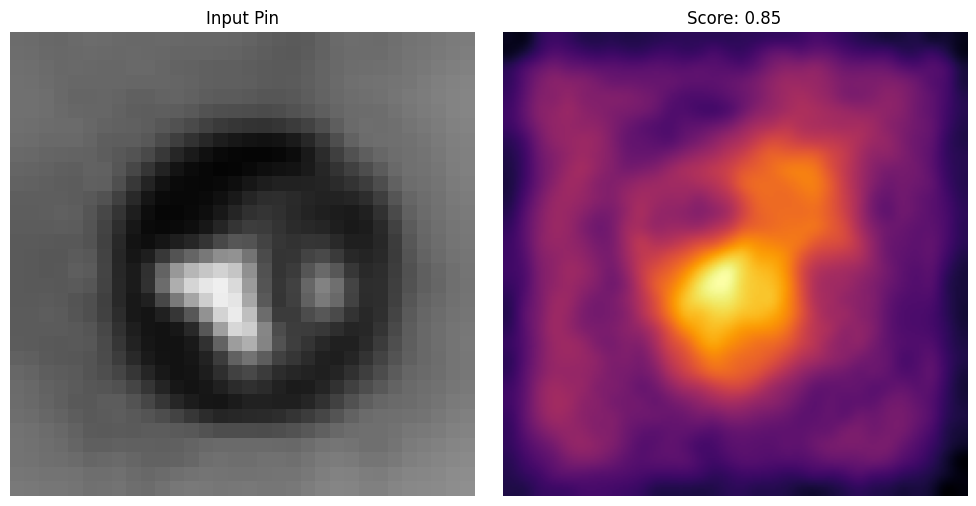

TorchInferencer is a legacy inferencer. Consider using Engine.predict() instead, which provides a more modern and feature-rich interface for model inference.
TRUST_REMOTE_CODE is set to True. Loading model using pickle module, which is inherently insecure and can lead to arbitrary code execution. Only set this to True if you TRUST the source of the checkpoint.


Anomalous


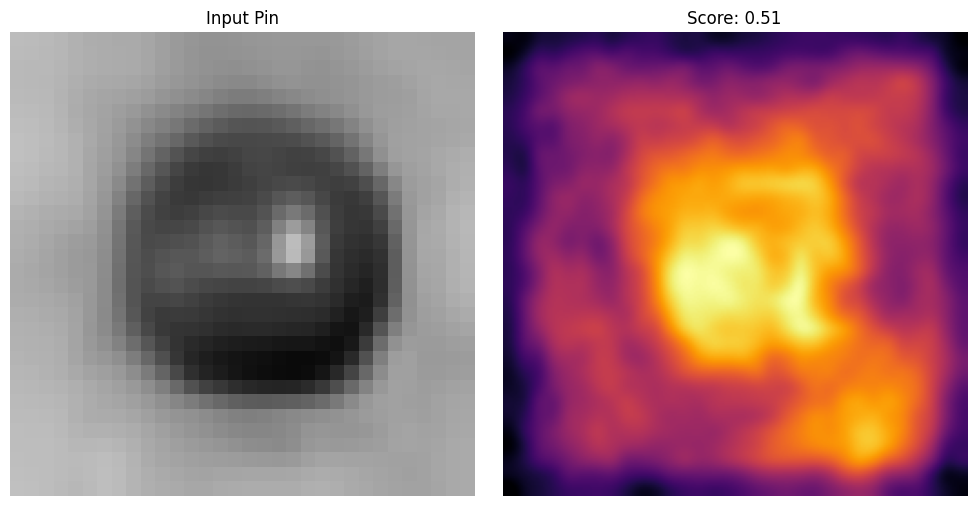

TorchInferencer is a legacy inferencer. Consider using Engine.predict() instead, which provides a more modern and feature-rich interface for model inference.
TRUST_REMOTE_CODE is set to True. Loading model using pickle module, which is inherently insecure and can lead to arbitrary code execution. Only set this to True if you TRUST the source of the checkpoint.


Anomalous


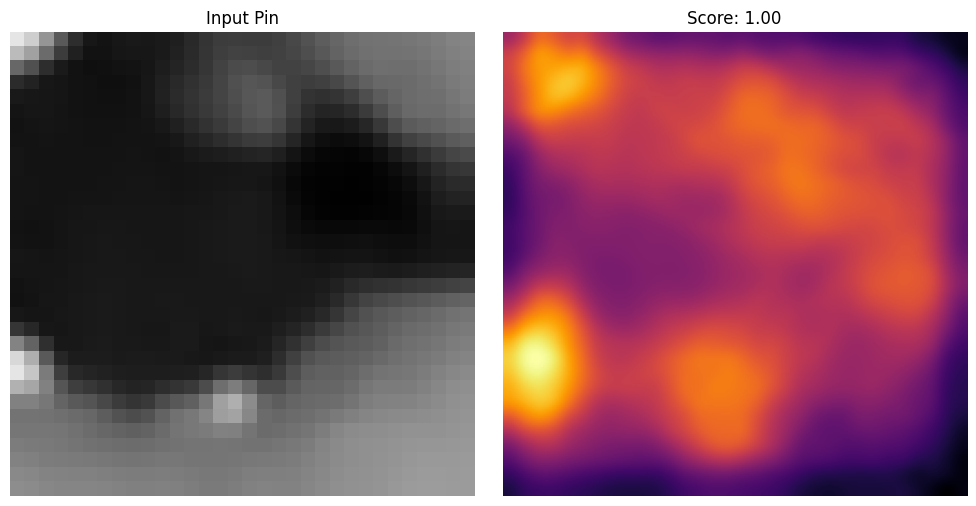

TorchInferencer is a legacy inferencer. Consider using Engine.predict() instead, which provides a more modern and feature-rich interface for model inference.
TRUST_REMOTE_CODE is set to True. Loading model using pickle module, which is inherently insecure and can lead to arbitrary code execution. Only set this to True if you TRUST the source of the checkpoint.


Anomalous


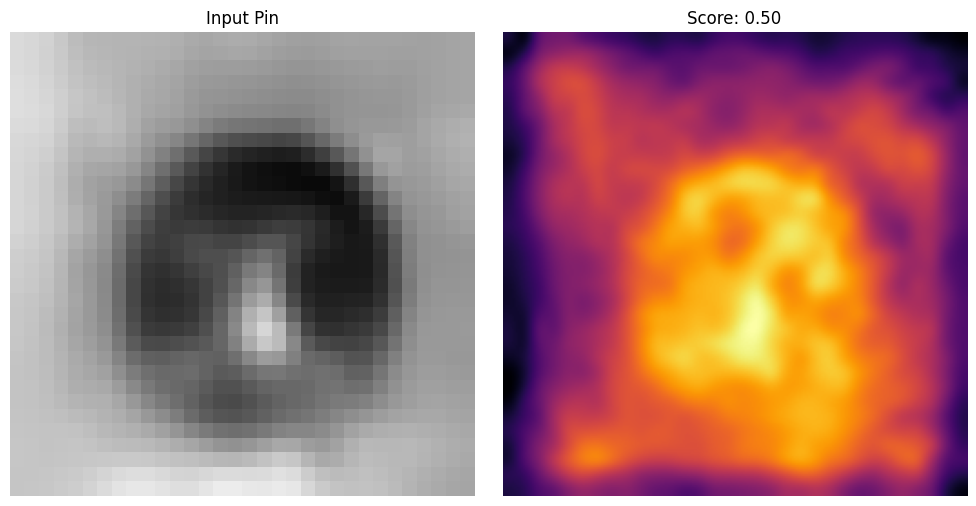

In [5]:
def inspect_pin(model_path, pin_image_path):
    inferencer = TorchInferencer(path=model_path, device='cuda')
    predictions = inferencer.predict(image=pin_image_path)
    
    # --- HANDLE HEATMAP SHAPE ---
    anom_map = predictions.anomaly_map
    if hasattr(anom_map, "cpu"): 
        anom_map = anom_map.cpu().numpy()
    anom_map = anom_map.squeeze() # Removes (1, 256, 256) -> (256, 256)

    # --- HANDLE SCORE FORMATTING ---
    # Convert Tensor to float using .item()
    score = predictions.pred_score.item() 

    if score > 0.5:
        print("Anomalous")
    else:
        print("Good")

    # Visualize
    fig, ax = plt.subplots(1, 2, figsize=(10, 5))
    
    # Original Image
    ax[0].imshow(cv2.cvtColor(cv2.imread(pin_image_path), cv2.COLOR_BGR2RGB))
    ax[0].set_title("Input Pin")
    ax[0].axis('off')
    
    # Anomaly Heatmap
    ax[1].imshow(anom_map, cmap='inferno') 
    ax[1].set_title(f"Score: {score:.2f}") # Now valid because 'score' is a float
    ax[1].axis('off')
    
    plt.tight_layout()
    plt.show()

img_path = "./datasets/socket_pins/test/defect/"
for img in os.listdir(img_path):
    inspect_pin("./results/Patchcore/socket_pins/latest/weights/torch/model.pt", f"{img_path}{img}")